# Comparision of Regression Algorithms on an Entire Machine Learning Process

 ##  Preprocessing

## Step 1-Regression: Read the Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('parkinsons.csv') 

## Step 2-Regression: Type Checking

In [96]:
df.tail()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
5870,42,61,0,142.79,22.485,33.485,0.00406,0.000031,0.00167,0.00168,...,0.160,0.00973,0.01133,0.01549,0.02920,0.025137,22.369,0.64215,0.55314,0.21367
5871,42,61,0,149.84,21.988,32.988,0.00297,0.000025,0.00119,0.00147,...,0.215,0.01052,0.01277,0.01904,0.03157,0.011927,22.886,0.52598,0.56518,0.12621
5872,42,61,0,156.82,21.495,32.495,0.00349,0.000025,0.00152,0.00187,...,0.244,0.01371,0.01456,0.01877,0.04112,0.017701,25.065,0.47792,0.57888,0.14157
5873,42,61,0,163.73,21.007,32.007,0.00281,0.000020,0.00128,0.00151,...,0.131,0.00693,0.00870,0.01307,0.02078,0.007984,24.422,0.56865,0.56327,0.14204
5874,42,61,0,170.73,20.513,31.513,0.00282,0.000021,0.00135,0.00166,...,0.171,0.00946,0.01154,0.01470,0.02839,0.008172,23.259,0.58608,0.57077,0.15336


In [97]:
type(df)

pandas.core.frame.DataFrame

In [98]:
df.shape

(5875, 22)

In [99]:
type(df['total_UPDRS'])

pandas.core.series.Series

In [100]:
#confirm where the column indexing begins
df.columns[0]

'subject#'

## Step 3-Regression Visualize The Data before Preprocessing

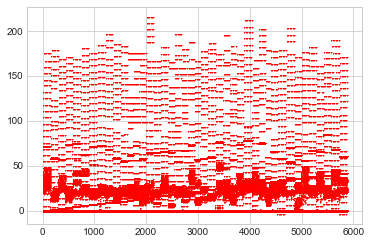

In [25]:
plt.style.use('seaborn-whitegrid')
plt.plot(df,'r+',linewidth=1, markersize=1); #additional parameters decrease plot size for better visual of distribution

## Step 4-Regression: Exploratory Analysis

In [26]:
from sklearn.cluster import KMeans

Instantiate a kmeans object and choose a value of k. Since we have two class variables of the response/target feature, we will choose a value of two; so two clusters.

The # of clusters to choose in this instance is more challenging; chose 8 as a larger K often produces more accurate clusters
due to the fact that the distances between all observations within a cluster and its centroids is minimized.
- Given the size of the dataset, k=8 seems reasonable
- Parameter tuning could be performed here, but is better reserved using cross validation after machine learning takes place

In [27]:
kmeans = KMeans(n_clusters=8)

Now let us identfiy the dataset's into a matrix of features and an independent vector (same as with classification). Since clustering algorithms are unsupervised learning, we will not use train/test split. **From reading the dataset descriptions it was learned that this dataset is has not one, but two response variables (multivariate). The two response variables are 'total_UPDRS' and 	'motor_UPDRS'; since total_UPDRS' values also contain the motor_UPDRS values, it is logical to eliminate the latter. (SEE PAIR WISE PLOTS; BOTH CORRELEATE EQUALLY WITH FEATURES) However, this conclusion is better reached after viewing the clustering results; the exploratory analysis will better aid this decision.** Since the response variables are in the middle, they must be indexed as so.

In [29]:
X = df[['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP','Shimmer','Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5', 'Shimmer:APQ11','Shimmer:DDA','NHR', 'HNR',
            'RPDE', 'DFA', 'PPE']].values
#pandas instead of numpy for convinience of operations
#pdX = df[['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
            #'Shimmer','Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5', 'Shimmer:APQ11','Shimmer:DDA','NHR', 'HNR',
            #'RPDE', 'DFA', 'PPE']]
y = df[['motor_UPDRS','total_UPDRS']].values
#pdy = df[['motor_UPDRS','total_UPDRS']]

In [30]:
kmeans.fit(X)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=8, n_init=10, n_jobs=1, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

We can see in the parameters output that kmeans++ was ran by default and 2 clusters for formed. (Kmeans++ having run means that the algorithm is repeated to ensure that our choice of k doesn't fall into the random intialization trap)

Let's print out the centroids and labels.

In [31]:
kmeans.cluster_centers_

array([[1.94640999e+01, 6.39188345e+01, 3.40270552e-01, 1.11279626e+02,
        5.92768991e-03, 4.15923205e-05, 2.86941727e-03, 3.19140479e-03,
        8.60819979e-03, 3.21151717e-02, 2.93396462e-01, 1.63015193e-02,
        1.89319355e-02, 2.54659938e-02, 4.89048907e-02, 3.04805911e-02,
        2.19412445e+01, 5.32575151e-01, 6.48086337e-01, 2.14210822e-01],
       [9.58101473e+00, 6.56824877e+01, 1.84942717e-01, 5.11089738e+01,
        5.59425532e-03, 4.33934534e-05, 2.74873977e-03, 2.87985270e-03,
        8.24648118e-03, 3.11765303e-02, 2.85995090e-01, 1.62161538e-02,
        1.83233388e-02, 2.45334534e-02, 4.86481997e-02, 2.41970638e-02,
        2.23166809e+01, 5.28460409e-01, 6.40882897e-01, 2.08942794e-01],
       [2.42238372e+01, 6.54825581e+01, 3.21220930e-01, 1.76423968e+02,
        6.22254360e-03, 4.46922965e-05, 2.98079942e-03, 3.24572674e-03,
        8.94322674e-03, 3.32243314e-02, 3.05847384e-01, 1.67585756e-02,
        1.93835174e-02, 2.74081541e-02, 5.02751744e-02, 2.8302

The distances are not overly large. So it seems the clustering is well perfomed.

In [32]:
kmeans.labels_

array([3, 3, 3, ..., 4, 2, 2])

Remember that the labels are numerical and continous now

#### Now we will also perform hierarichal clustering. With two types of clustering algorithms, we will have a very accurate breakdown of our model's clusters.

In [33]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
#We can either use single linkage (euclidean distance of the closest points of the clusters in the dendrogram)
#or complete linkage (distance of furthest points of the clusters in the dendrogram)
mergings = linkage(X, method='single') #chose single linkage #pass in our matrix of features as the first parameter
#and what HC will merge on (we are using agglomerative HC)

Plot the result of HC, our dendrogram. However, recall that in order to run HC, we need a scaled dataset. We discovered in steps 2-3, that our dataset was not scaled. Let us first run feature scaling and then plot the dendrogram of HC.

In [34]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

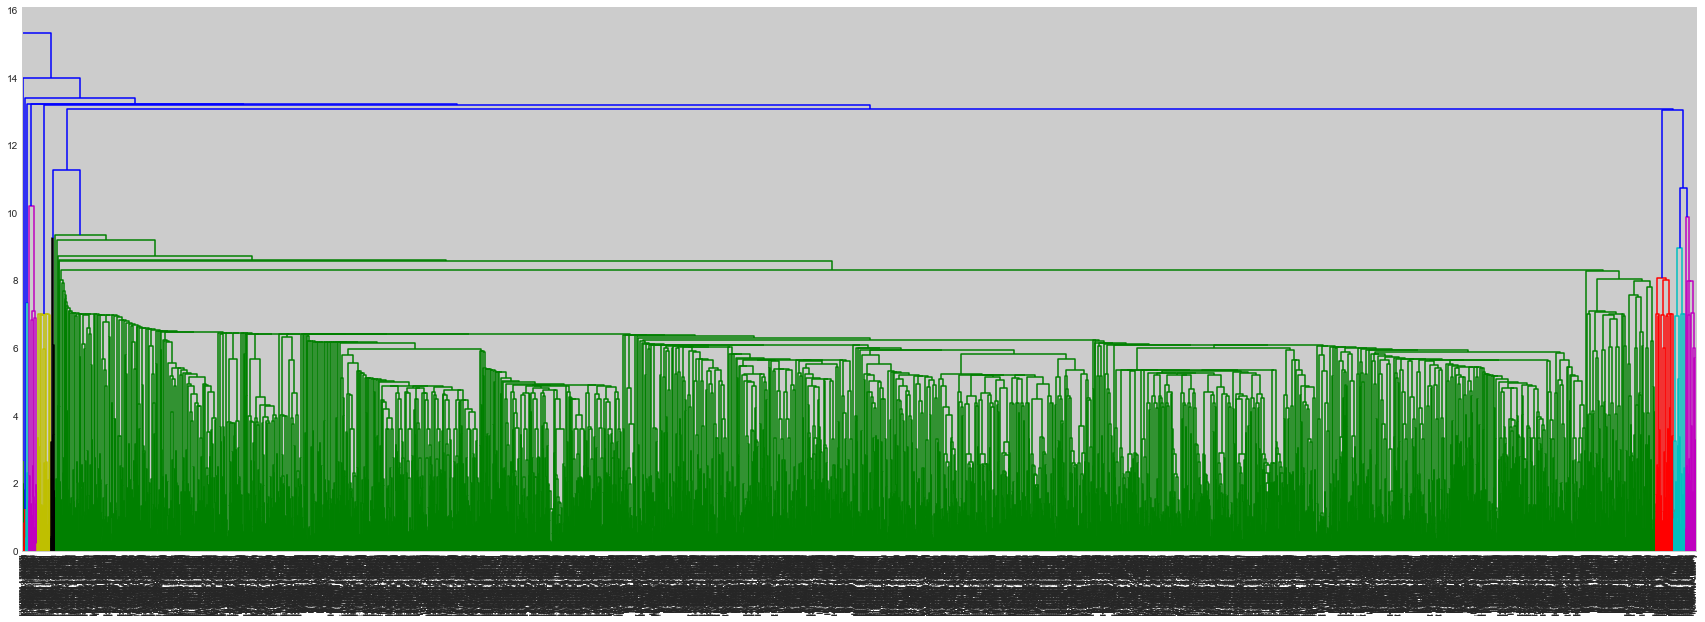

In [33]:
plt.figure(figsize=(30, 10))
dendrogram(mergings,
           labels=y,
)
plt.show()

It is not necessary to also run HC and fit the model on our data set. The goal of this stage was simply to explore our data, and the dendrograms as well as kmeans_labels functions did exactly that. Now, it is time to move on to the next step, in which we will try to reduce the features of our dataset and any noise that accompanies features which do not add to the analysis or have any impact on the correleations.**Also note, this is a good example of understanding why certain algorithms are better suited for others. One of HC's weaknesses is large datasets. Seeing as this is a large dataset we can see how even larger datasets would lose HC's benefits of visual understanding of the nested dendrogram.**

## Step 5.2: Feature Elimination- Reducing the noise of our data

**From reading the dataset descriptions, it was revealed that this particular dataset had two response variables-rather than one. For educational purposes, this is one of the few datasets that I could find, which was large enough to pose a greater challenge than the data set used in the classification run (since it has more attributes), but also be feasible to complete (it did not significantly slow the results or contain data that was so variant that preprocessing and analysis would be outside the scope of this assignment). As a result, since one of the response variables is just an ... I chose to eliminate it from the dataset. Reading the rest of the dataset did not reveal any other indicative information regarding the features and correlations with the response variable. Therefore, we will apply the fast learning scheme just as it was applied in the classification run.**
The two response variables are: 'motor_UPDRS' & 'total_UPDRS'

The Fast Learning Scheme: Multiple Linear Regression

In [2]:
#remove column 'motor_UPDRS' from the dataset
df.columns

Index(['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS',
       'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
       'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'],
      dtype='object')

In [3]:
df.drop('motor_UPDRS', axis = 1, inplace=True)

In [4]:
#Confirm that feature was eliminated
df.head()

,subject#,age,sex,test_time,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [5]:
# Re-assign the matrix of features and independent vector (because of the exclusion of motor_UPDRS )
X = df[['subject#','age','sex','test_time','Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP','Jitter:PPQ5', 'Jitter:DDP', 
            'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR',
            'RPDE', 'DFA', 'PPE']].values
y = df.total_UPDRS.values 
#y = y.reshape(-1,1)
# Avoiding the Dummy Variable Trap
#X = X[:, 1:]
y.shape

(5875,)

In [6]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [7]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)
sc_y = StandardScaler()
#y_train = y_train.reshape(-1,1)
#y_test.reshape(-1,1)
y_train = sc_y.fit_transform(y_train)

ValueError: Expected 2D array, got 1D array instead:
array=[40.84  28.322 39.408 ... 23.122 26.002 16.559].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

ALTERNATIVE BETTER METHOD NOT USED HERE: SciKit Documentation, Recursive Feature Elimination (an attribute selection scheme as learned in class)
http://scikit-learn.org/stable/auto_examples/feature_selection/plot_rfe_with_cross_validation.html#sphx-glr-auto-examples-feature-selection-plot-rfe-with-cross-validation-py

In [70]:
# Fitting Multiple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predicting the Test set results
y_pred = regressor.predict(X_test)
#NO EVALUATION, NOT RUNNING ALGORITHM TO LEARN, BUT TO REDUCE FEATURES, the evaluation of multiple linear regression will
#occur in step 7

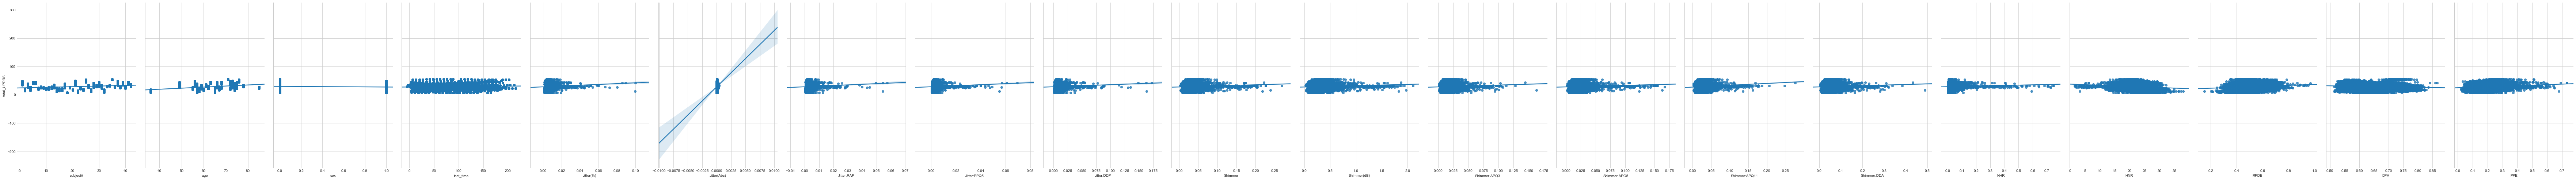

In [113]:
import seaborn as sns
# allow plots to appear within the notebook
%matplotlib inline
sns.pairplot(df, x_vars=['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
            'Shimmer','Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5', 'Shimmer:APQ11','Shimmer:DDA','NHR', 'HNR',
            'RPDE', 'DFA', 'PPE'], y_vars=['total_UPDRS'], size=7, aspect=0.7, kind='reg')

## Step 6-Regression: Dimensionality Reduction

In [43]:
from sklearn import decomposition #now import decomposition lib, PCA is defined in this library

In [47]:
#Main PCA Algorithm
pca = decomposition.PCA(n_components=6) #transform data set (this line only calculates) so you only see 6 columns in array
pca.fit(df) #now fit transformation/reduction technique to our df
reducedset = pca.transform(df) #after fitting to df, transform original to new data

In [48]:
#Ensure that dimensionality reduction has occured, indeed only 6 columns remain but the number of instances is still the same
reducedset.shape

(5875, 6)

## Step 7-Regression Algorithms & Evaluation

In [116]:
#Resplit data
# Re-assign the matrix of features and independent vector (because of the exclusion of motor_UPDRS )
X = reducedset
y = df[['total_UPDRS']].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [117]:
print(X_train.shape)
print(X_test.shape)


(4700, 6)
(1175, 6)


In [118]:
#Fit Multiple Linear Regression
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Predicting the Test set results
y_mlr = mlr.predict(X_test)
#y_mlr = sc_y.inverse_transform(y_mlr)

In [119]:
# Fit SVR
from sklearn.svm import SVR
svr = SVR(kernel = 'rbf')
svr.fit(X, y)

# Predicting test set result
y_svr = svr.predict(X_test)
y_svr = sc_y.inverse_transform(y_pred)

C:\Users\Primary\Anaconda3\lib\site-packages\sklearn\utils\validation.py:578: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [120]:
y_svr

array([[30.84949003],
       [37.91217753],
       [24.59931482],
       ...,
       [35.64331083],
       [27.33014618],
       [24.57927744]])

##### Parameter Tuning: A Consideration (Literature)
Often we are not satisfied with the results of our algorithm; or we think we can do better. **Here, in our scenario, we may wish to adjust which k would be suitable for our algorithm**. So, to remedy this we can different k-values of KNN. Now you may wonder, how can we possibly try every single value. The good news is we don't have to, k is best left to be a small positive integer. However, small may be relative to the size of your dataset. Fortunately, python isn't just a data science tool, but a full fledged programming language as well, we can loop through several k-value candidates using python's range function, and then plot the results.

In [8]:
# Fit KNN Regression
from sklearn.neighbors import KNeighborsRegressor
knnregressor = KNeighborsRegressor(n_neighbors=6)
knnregressor.fit(X, y) 
y_knnr = knnregressor.predict(X_test)
y_knnr = sc_y.inverse_transform(y_knnr)


NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this method.

**EVALUATION**

Regressions algorithms are parametric and use forumulas to output continous values. There are no true or false, only continous variables. Therefore, classification metrics based on confusion matricies or ROC/AUC are not applicable. Instead, we use the concept of the cost function; in other words we evaluate models based on how effectively they minimize residual error. Residuals are calculated by subtracting the actual observations' numeric values from the predicted values. A way to visualize this is that we are trying to minimize the displacement from the line of best fit and the actual data points. There are three metrics commonly used in regression. Note: ALL BELOW METRICS take total the (true - predicted) of all data points. However, not all utilze the concept of LEAST SQUARES. This concept simply means squaring the residual displacements so that our model is even more accurate. (see why below)
- Mean Absolute Error (MAE): A simple average of the sum of residuals. Interpretable in same units as response variable. Does not utilize the least squares regression concept.
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

Note: Since we are calculating the residual error in each case, a lower number is desired as it equates to a lower error of our predictive model's capabilities.

In [ ]:
# calculate RMSE using scikit-learn
print(np.sqrt(metrics.mean_squared_error(y_test, y_knnr)))
print(np.sqrt(metrics.mean_squared_error(y_test, y_svr)))
print(np.sqrt(metrics.mean_squared_error(y_test, y_mlr)))

# calculate MSE using scikit-learn
print(metrics.mean_squared_error(y_test, y_knnr)))
print(metrics.mean_squared_error(y_test, y_svr)))
print(metrics.mean_squared_error(y_test, y_mlr)))

# calculate MAE using scikit-learn
print(metrics.mean_absolute_error(y_test, y_knnr)))
print(metrics.mean_absolute_error(y_test, y_svr)))
print(metrics.mean_absolute_error(y_test, y_mlr)))

### Step 7 Learning & Evaluation without dimensionality reduction

In [ ]:
#Resplit data
# Re-assign the matrix of features and independent vector (because of the exclusion of motor_UPDRS )
X = df[['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
            'Shimmer','Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5', 'Shimmer:APQ11','Shimmer:DDA','NHR', 'HNR',
            'RPDE', 'DFA', 'PPE']].values
y = df[['total_UPDRS']].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
#Fit Multiple Linear Regression
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Predicting the Test set results
y_mlr = mlr.predict(X_test)
#y_mlr = sc_y.inverse_transform(y_mlr)

In [ ]:
# Fit SVR
from sklearn.svm import SVR
svr = SVR(kernel = 'rbf')
svr.fit(X, y)

# Predicting test set result
y_svr = svr.predict(X_test)
y_svr = sc_y.inverse_transform(y_pred)

In [ ]:
# Fit KNN Regression
from sklearn.neighbors import KNeighborsRegressor
knnregressor = KNeighborsRegressor(n_neighbors=)
knnregressor.fit(X, y) 
y_knnr = knnregressor.predict(X_test)
y_knnr = sc_y.inverse_transform(y_knnr)

**EVALUATION**

In [ ]:
# calculate RMSE using scikit-learn
print(np.sqrt(metrics.mean_squared_error(y_test, y_knnr)))
print(np.sqrt(metrics.mean_squared_error(y_test, y_svr)))
print(np.sqrt(metrics.mean_squared_error(y_test, y_mlr)))

# calculate MSE using scikit-learn
print(metrics.mean_squared_error(y_test, y_knnr)))
print(metrics.mean_squared_error(y_test, y_svr)))
print(metrics.mean_squared_error(y_test, y_mlr)))

# calculate MAE using scikit-learn
print(metrics.mean_absolute_error(y_test, y_knnr)))
print(metrics.mean_absolute_error(y_test, y_svr)))
print(metrics.mean_absolute_error(y_test, y_mlr)))